# ***IMPORT PICTURE THAT YOU WANT THE MODEL TO PRIDCIT***

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 5.jpg to 5.jpg


# **Import Libraries**

In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ***Step 1: Load and Preprocess the MNIST Dataset***


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Normalize pixel values to [0, 1]**

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# **Reshape data to match the input shape of the model**

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# **Convert labels to one-hot encoding**

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ***Step 2: Define and Train the Model***

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compile the model**

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# **Train the model**

In [ ]:
print("Training the model...")
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Training the model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9125 - loss: 0.2900 - val_accuracy: 0.9810 - val_loss: 0.0593
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 24ms/step - accuracy: 0.9851 - loss: 0.0489 - val_accuracy: 0.9854 - val_loss: 0.0430
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.9918 - loss: 0.0279 - val_accuracy: 0.9870 - val_loss: 0.0415
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.9947 - loss: 0.0177 - val_accuracy: 0.9868 - val_loss: 0.0368
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9966 - loss: 0.0117 - val_accuracy: 0.9862 - val_loss: 0.0427
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9970 - loss: 0.0090 - val_accuracy: 0.9855 - val_loss: 0.0531
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.9978 - loss: 0.0066 - val_accuracy: 0.9879 - val_loss: 0.0452
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/ste

# **Save the trained model**

In [ ]:
model.save('digit_recognition_model.h5')
print("Model trained and saved as 'digit_recognition_model.h5'.")

Model trained and saved as 'digit_recognition_model.h5'.


# ***Step 3: Preprocessing Function for Custom Image***

In [ ]:
def preprocess_image(digit5_jpg):

    img = Image.open(digit5_jpg).convert('L')
    img = img.resize((28, 28))

    plt.imshow(img, cmap='gray')
    plt.title("Preprocessed Image")
    plt.show()

    img_array = np.array(img) / 255.0
    return img_array.reshape(1, 28, 28, 1)


    img = img.resize((28, 28))

    plt.imshow(img, cmap='gray')
    plt.title("Preprocessed Image")
    plt.show()


    img_array = np.array(img) / 255.0

    return img_array.reshape(1, 28, 28, 1)

# ***4. Debugging Common Issues***

If the prediction seems incorrect:
1. Image Quality: Ensure the handwritten digit is clear, centered, and well-lit.
2. Contrast Adjustment: If the digit is faint, enhance the contrast using Matplotlib.


In [ ]:
import matplotlib.pyplot as plt

def preprocess_image(digit5_jpg):
    img = Image.open(digit5_jpg).convert('L')
    img = img.resize((28, 28))


    img_array = np.array(img)
    img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min()) * 255
    enhanced_img = Image.fromarray(img_array.astype(np.uint8))

    plt.imshow(enhanced_img, cmap='gray')
    plt.title("Preprocessed Image (Enhanced Contrast)")
    plt.show()

    img_array = np.array(enhanced_img) / 255.0
    return img_array.reshape(1, 28, 28, 1)

# ***Step 4: Test with Your Custom Handwritten Digit***

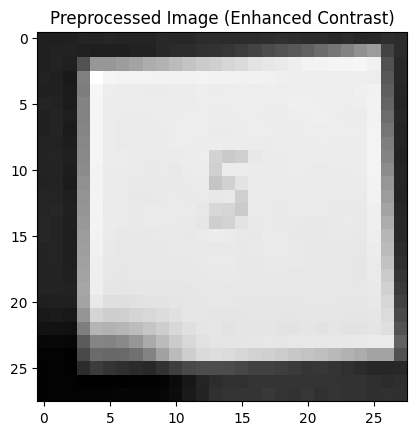

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Digit: 6


In [ ]:
image_path = '/content/digit5.jpg'
processed_image = preprocess_image(image_path)

model = load_model('digit_recognition_model.h5')
prediction = model.predict(processed_image)
predicted_digit = np.argmax(prediction)

print(f"Predicted Digit: {predicted_digit}")